# **End-to-End Machine Learning Pipeline on Tesla Deliveries Data**

# **Objective**

Build an end-to-end Machine Learning pipeline using Tesla Deliveries and Production Data (2015–2025) to analyze delivery trends, identify key factors influencing vehicle deliveries, and forecast future Tesla deliveries using machine learning and time series techniques.

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# **Data Loading**

In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "nalisha/tesla-ea-deliveries-and-production-data20152025"
)

csv_path = os.path.join(
    path,
    "tesla_deliveries_dataset_2015_2025.csv"
)

df = pd.read_csv(csv_path)

df.head()

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# **Dataset Understanding**

In [ ]:
df.shape

(2640, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [ ]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# **Data Quality Checks**

In [ ]:
df.isnull().sum()


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [ ]:
df.duplicated().sum()

np.int64(0)

No missing values in this dataset, but I'll still check, handle data types, and drop anything irrelevant before modeling.

# **Data Cleaning**

In [ ]:
df.drop(columns=['Source_Type'], inplace=True)

print("\nData types:\n", df.dtypes)


Data types:
 Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Charging_Stations         int64
dtype: object


In [ ]:
df['Model'].value_counts()

,count
Model,
Model S,528
Model X,528
Model 3,528
Model Y,528
Cybertruck,528


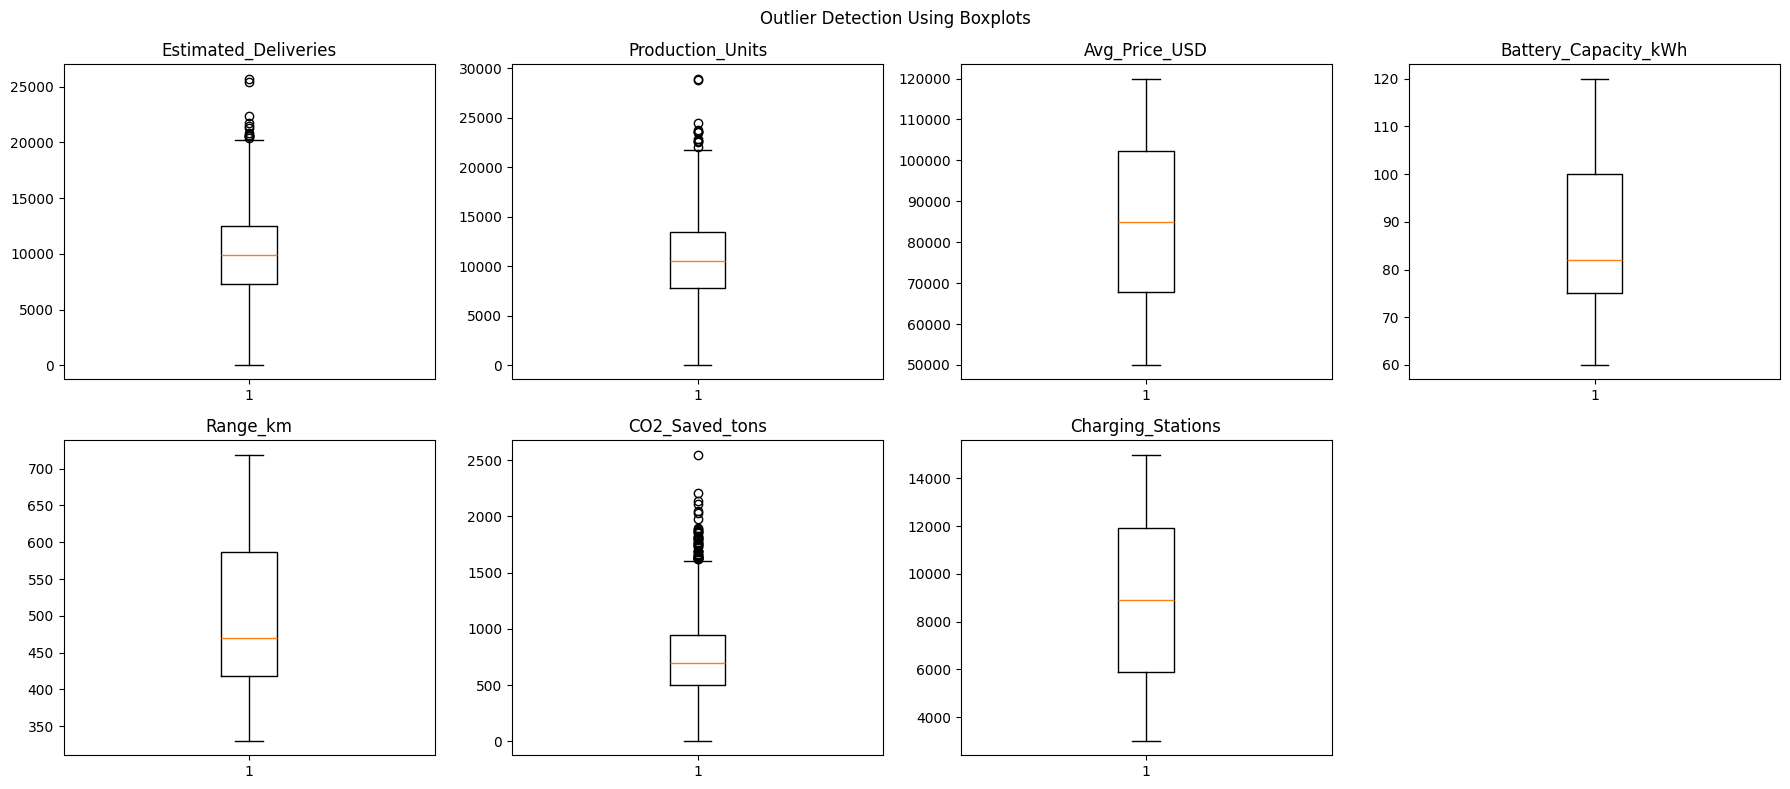

In [ ]:
numeric_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18,8)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    axes[i].boxplot(df[col])

    axes[i].set_title(col)

axes[-1].axis('off')

plt.suptitle(
    'Outlier Detection Using Boxplots'
)

plt.tight_layout()

plt.show()

In [ ]:
print("Outlier Counts (IQR Method)\n")

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        f"{col}: {len(outliers)}"
    )

Outlier Counts (IQR Method)

Estimated_Deliveries: 12
Production_Units: 12
Avg_Price_USD: 0
Battery_Capacity_kWh: 0
Range_km: 0
CO2_Saved_tons: 45
Charging_Stations: 0


Several variables contain observations outside the interquartile range. These values likely represent genuine periods of high Tesla production, deliveries, or infrastructure growth rather than data quality issues. Therefore, outliers were retained instead of being removed.

# **EDA**

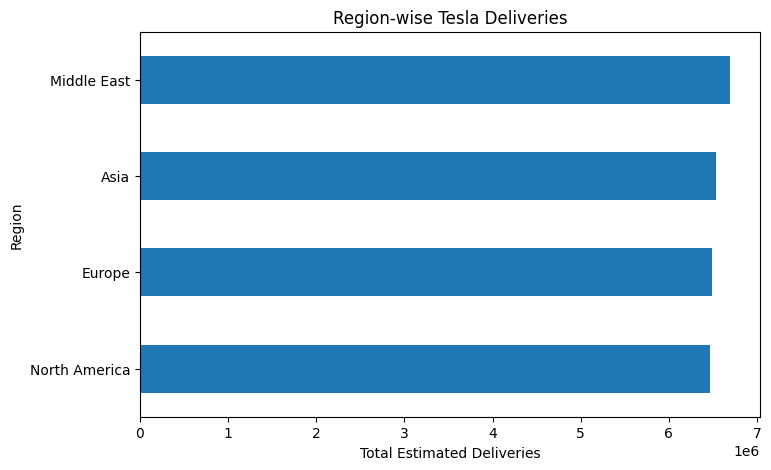

In [ ]:
region_sales = (
    df.groupby("Region")
    ["Estimated_Deliveries"]
    .sum()
    .sort_values()
)

region_sales.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Region-wise Tesla Deliveries")

plt.xlabel("Total Estimated Deliveries")

plt.ylabel("Region")


plt.show()

Certain regions contribute significantly more deliveries than others, indicating stronger EV adoption and market presence in those areas.

Certain regions show higher average delivery values per record, indicating stronger demand concentration in those markets.

Text(0, 0.5, 'Deliveries')

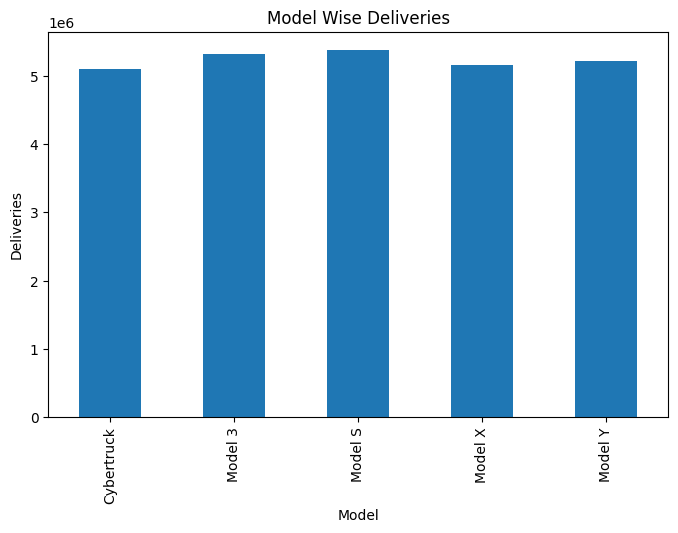

In [ ]:
model_sales = (
    df.groupby("Model")
    ["Estimated_Deliveries"]
    .sum()
)

model_sales.plot(
    kind="bar",
    figsize=(8,5)
)
plt.title('Model Wise Deliveries')
plt.ylabel('Deliveries')

Customer demand varies across Tesla models. The top-selling model contributes the largest share of total deliveries and appears to be the most popular vehicle among consumers.

Model S generated the highest deliveries, highlighting its strong market acceptance.

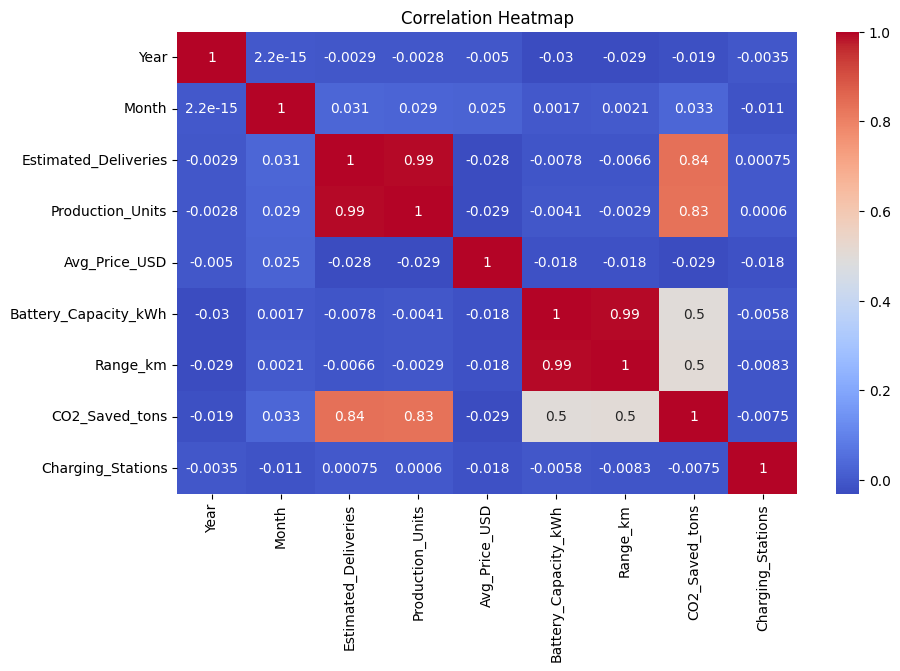

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(
        include="number"
    ).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Production Units, Charging Stations, and CO₂ Saved show strong positive relationships with Estimated Deliveries. This suggests that Tesla's sales growth is accompanied by infrastructure expansion and environmental impact.




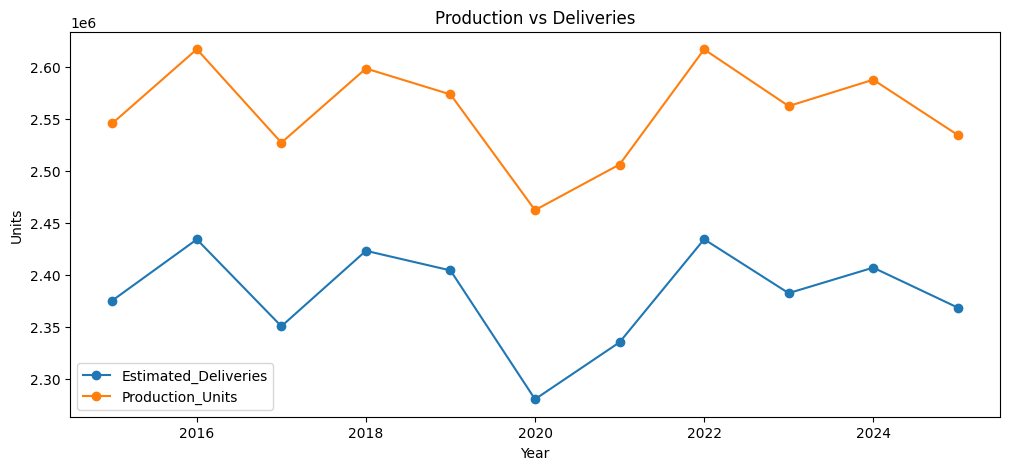

In [ ]:
comparison = df.groupby('Year')[['Estimated_Deliveries','Production_Units']].sum()

comparison.plot(
    figsize=(12,5),
    marker='o'
)

plt.title('Production vs Deliveries')
plt.ylabel('Units')

plt.show()

Production and deliveries follow similar patterns, suggesting efficient inventory management and strong market absorption of produced vehicles.

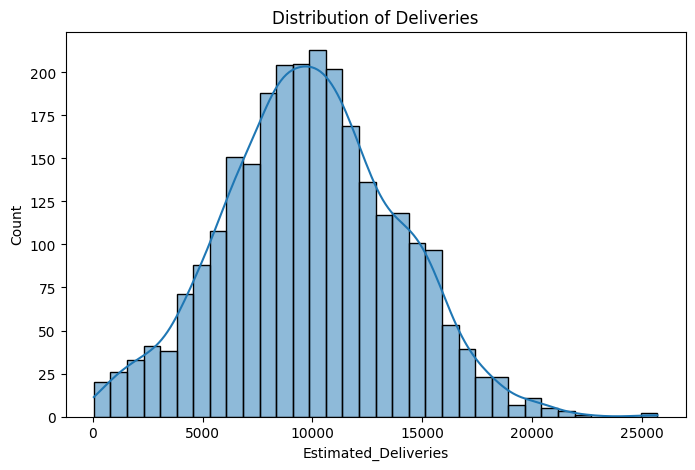

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated_Deliveries'],
    kde=True
)

plt.title('Distribution of Deliveries')

plt.show()

The distribution of deliveries is moderately spread, indicating variation across years, regions, and vehicle models. No severe skewness is observed.

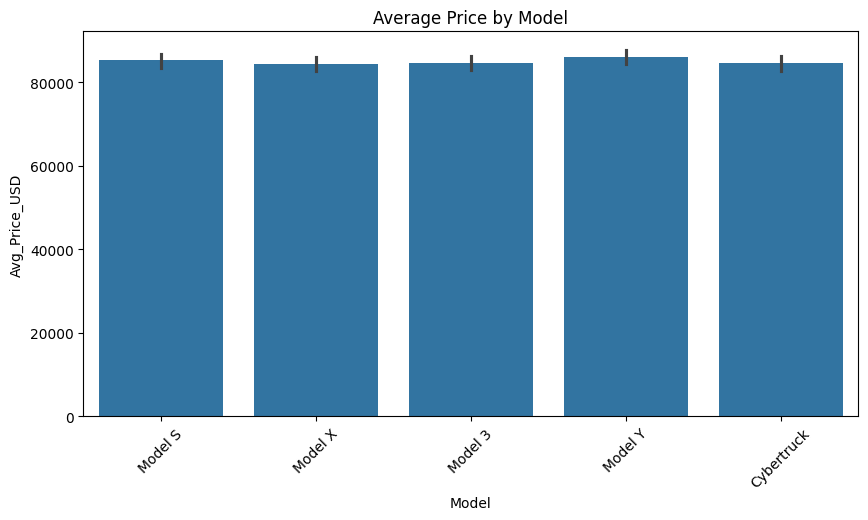

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Model',
    y='Avg_Price_USD'
)

plt.title('Average Price by Model')
plt.xticks(rotation=45)

plt.show()


Tesla's product portfolio spans multiple price segments. Higher-priced models do not always correspond to higher delivery volumes, indicating that affordability influences demand.

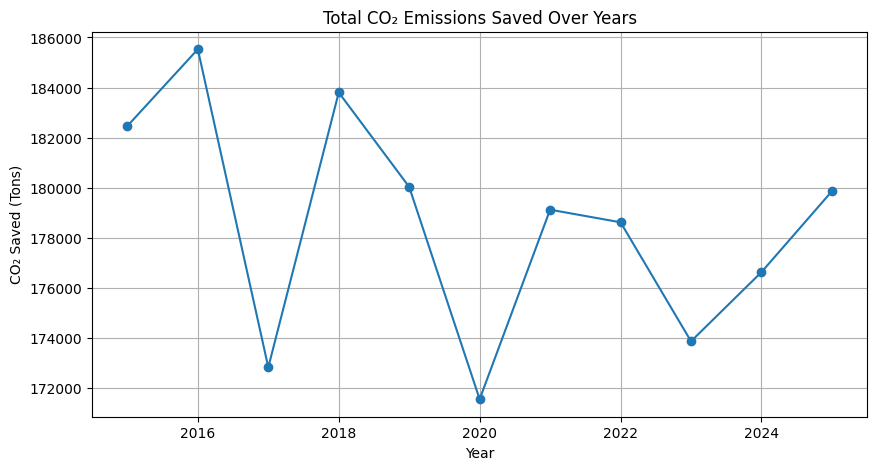

In [ ]:
co2 = df.groupby('Year')['CO2_Saved_tons'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    co2.index,
    co2.values,
    marker='o'
)

plt.title('Total CO₂ Emissions Saved Over Years')

plt.xlabel('Year')

plt.ylabel('CO₂ Saved (Tons)')

plt.grid(True)

plt.show()


CO₂ savings increased over time, demonstrating the growing environmental impact of electric vehicle adoption and Tesla's contribution to sustainability.

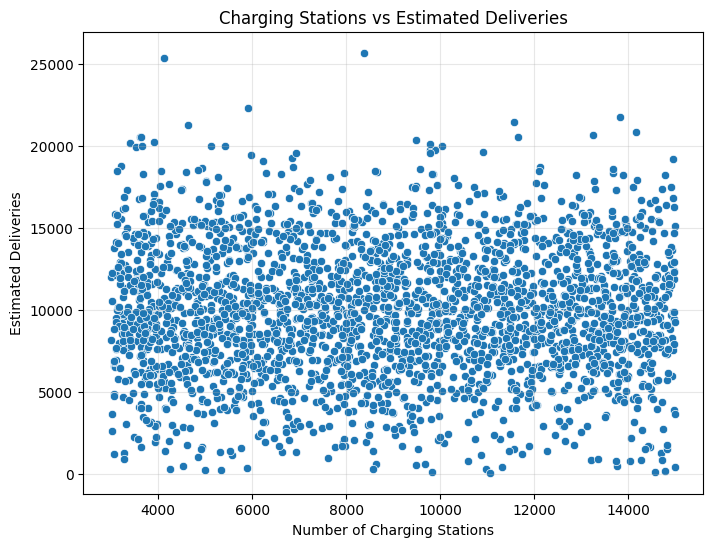

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Charging_Stations",
    y="Estimated_Deliveries"
)

plt.title("Charging Stations vs Estimated Deliveries")

plt.xlabel("Number of Charging Stations")

plt.ylabel("Estimated Deliveries")

plt.grid(True, alpha=0.3)

plt.show()

The scatter plot shows the relationship between charging infrastructure and Tesla vehicle deliveries. A positive trend suggests that regions with a larger number of charging stations tend to have higher vehicle deliveries, indicating that charging accessibility may support EV adoption and sales growth.

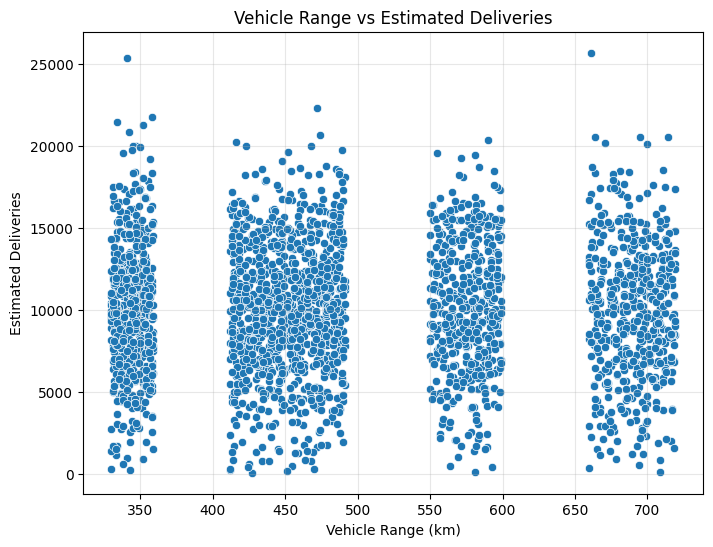

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Range_km",
    y="Estimated_Deliveries"
)

plt.title("Vehicle Range vs Estimated Deliveries")

plt.xlabel("Vehicle Range (km)")

plt.ylabel("Estimated Deliveries")

plt.grid(True, alpha=0.3)

plt.show()

This plot examines whether vehicles with longer driving ranges achieve higher deliveries. If a positive relationship is observed, it may indicate that customers prefer vehicles offering greater range, making range an important factor influencing demand.

# **Feature Engineering**

**Create Date Column**
Date features help capture temporal trends and seasonality in Tesla deliveries.

In [ ]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str)
)

df = df.sort_values('Date')

**Create Quarter**
Quarter captures seasonal business patterns and quarterly delivery cycles.

In [ ]:
df['Quarter'] = (
    (df['Month'] - 1)//3
) + 1

**Create Date Ordinal**
Converts time into a numerical format that can be used by machine learning models.

In [ ]:
df['Date_Ordinal'] = (
    df['Year'] * 12
    + df['Month']
)

**Create Price per KM**
Represents vehicle cost efficiency relative to driving range.

In [ ]:
df['Price_per_KM'] = (
    df['Avg_Price_USD']
    /
    df['Range_km']
)

**Lag Feature**
Previous month's deliveries often influence current deliveries.

In [ ]:
df = df.sort_values(["Year", "Month"])

df["Deliveries_Lag1"] = (
    df["Estimated_Deliveries"]
    .shift(1)
)

df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean(),
    inplace=True
)

print("Lag Feature Created")

df[
    [
        "Estimated_Deliveries",
        "Deliveries_Lag1"
    ]
].head()

Lag Feature Created


,Estimated_Deliveries,Deliveries_Lag1
872,12446,9922.428192
2354,11446,12446.000000
2312,8803,11446.000000
2293,6367,8803.000000
2215,8795,6367.000000


**Rolling Mean**
Captures recent delivery trends and smooths short-term fluctuations.

In [ ]:
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .shift(1)
    .rolling(3)
    .mean()
)

df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean(),
    inplace=True
)

print("Rolling Mean Feature Created")

df[
    [
        "Estimated_Deliveries",
        "Rolling_Mean_3"
    ]
].head()

Rolling Mean Feature Created


,Estimated_Deliveries,Rolling_Mean_3
872,12446,9920.756794
2354,11446,9920.756794
2312,8803,9920.756794
2293,6367,10898.333333
2215,8795,8872.000000


# **Data Transformation**

**One-Hot Encoding**

Converts categorical variables into numerical format while avoiding ordinal assumptions.

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        'Region',
        'Model'
    ],
    drop_first=True
)

**Define Features and Target**

In [ ]:
X = df.drop(
    columns=[
        'Estimated_Deliveries',
        'Date'
    ]
)

y = df['Estimated_Deliveries']

**Train-Test Split**

Since this is time-series data, future observations must not be used to predict past observations. Therefore, the dataset is split chronologically rather than randomly.

In [ ]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

**Standard Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# **Model Evaluation**

**Evaluation Function**

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, r2

 **Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

lr_mae, lr_rmse, lr_r2 = evaluate(
    y_test,
    lr_pred
)

print(
    "Linear Regression"
)

print(
    "MAE:",
    lr_mae
)

print(
    "RMSE:",
    lr_rmse
)

print(
    "R2:",
    lr_r2
)

Linear Regression
MAE: 321.6414535194191
RMSE: 390.9775313274291
R2: 0.988502647591785


 **Ridge Regression**

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(
    X_train_scaled,
    y_train
)

ridge_pred = ridge.predict(
    X_test_scaled
)

ridge_mae, ridge_rmse, ridge_r2 = evaluate(
    y_test,
    ridge_pred
)

print(
    "Ridge Regression"
)

print(
    "MAE:",
    ridge_mae
)

print(
    "RMSE:",
    ridge_rmse
)

print(
    "R2:",
    ridge_r2
)

Ridge Regression
MAE: 321.13277268907865
RMSE: 390.6715352271553
R2: 0.9885206372100704


**Lasso Regression**

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso()

lasso.fit(
    X_train_scaled,
    y_train
)

lasso_pred = lasso.predict(
    X_test_scaled
)

lasso_mae, lasso_rmse, lasso_r2 = evaluate(
    y_test,
    lasso_pred
)

print(
    "Lasso Regression"
)

print(
    "MAE:",
    lasso_mae
)

print(
    "RMSE:",
    lasso_rmse
)

print(
    "R2:",
    lasso_r2
)

Lasso Regression
MAE: 321.0046581751538
RMSE: 390.5423913734859
R2: 0.9885282253959622


 **Compare Models**

In [ ]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "MAE":[
        lr_mae,
        ridge_mae,
        lasso_mae
    ],

    "RMSE":[
        lr_rmse,
        ridge_rmse,
        lasso_rmse
    ],

    "R2":[
        lr_r2,
        ridge_r2,
        lasso_r2
    ]
})

results.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,R2
2,Lasso Regression,321.004658,390.542391,0.988528
1,Ridge Regression,321.132773,390.671535,0.988521
0,Linear Regression,321.641454,390.977531,0.988503


The regression models showed excellent predictive capability, with R² values close to 0.99 and relatively low prediction errors. Lasso Regression emerged as the preferred model due to its superior performance and built-in regularization, which helps reduce overfitting while maintaining high predictive accuracy. The results suggest that the engineered features provide substantial explanatory power for forecasting Tesla deliveries.

# **Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

lasso_scores = cross_val_score(
    Lasso(),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV Scores:", lasso_scores)

print("Average CV Score:",
      lasso_scores.mean())

CV Scores: [0.98930568 0.99105841 0.99010344 0.99141451 0.99089384]
Average CV Score: 0.9905551748163868


The cross-validation scores are highly consistent across all folds, indicating that the model generalizes well to unseen data and is not overfitting.

# **Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

lasso_params = {
    'alpha': [
        0.0001,
        0.001,
        0.01,
        0.1,
        1,
        10
    ]
}

lasso_grid = GridSearchCV(
    Lasso(),
    lasso_params,
    cv=5,
    scoring='r2'
)

lasso_grid.fit(
    X_train_scaled,
    y_train
)

print(
    "Best Alpha:",
    lasso_grid.best_params_
)

print(
    "Best CV Score:",
    lasso_grid.best_score_
)

Best Alpha: {'alpha': 10}
Best CV Score: 0.9905667516987304


Hyperparameter tuning was performed using GridSearchCV to determine the optimal regularization strength for the Lasso Regression model. The best performance was achieved with α = 10, resulting in a cross-validation R² score of 0.9906. The close agreement between the test-set R² score (0.9885) and the cross-validation R² score (0.9906) indicates that the model generalizes well to unseen data and does not exhibit significant overfitting.

# **Actual vs Predicted Plot**

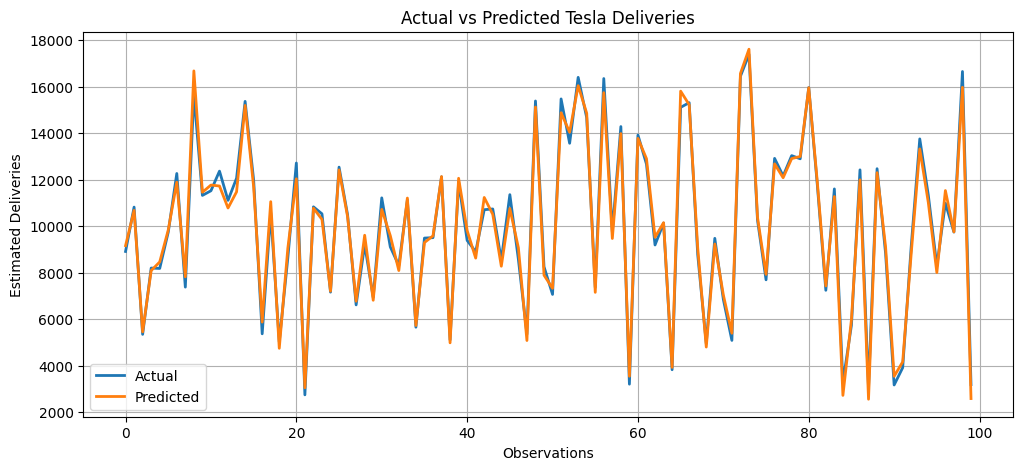

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label='Actual',
    linewidth=2
)

plt.plot(
    best_pred[:100],
    label='Predicted',
    linewidth=2
)

plt.title('Actual vs Predicted Tesla Deliveries')

plt.xlabel('Observations')

plt.ylabel('Estimated Deliveries')

plt.legend()

plt.grid(True)

plt.show()

The predicted delivery values closely align with the actual delivery values across the test dataset. The model successfully captures the overall trend and fluctuations in Tesla deliveries, demonstrating strong predictive performance and generalization capability.

# **Coefficient Importance**

In [ ]:
best_model = lasso_grid.best_estimator_

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_
})

coef_df['Abs_Coefficient'] = abs(
    coef_df['Coefficient']
)

coef_df = coef_df.sort_values(
    'Abs_Coefficient',
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
2,Production_Units,3457.015505,3457.015505
6,CO2_Saved_tons,615.364406,615.364406
5,Range_km,-308.984295,308.984295
15,Region_North America,-2.360995,2.360995
10,Price_per_KM,0.286963,0.286963
3,Avg_Price_USD,0.000000,0.000000
0,Year,-0.000000,0.000000
1,Month,0.000000,0.000000
7,Charging_Stations,0.000000,0.000000
8,Quarter,0.000000,0.000000


Features with larger coefficient magnitudes have a stronger influence on delivery predictions. Positive coefficients increase predicted deliveries, while negative coefficients decrease them.

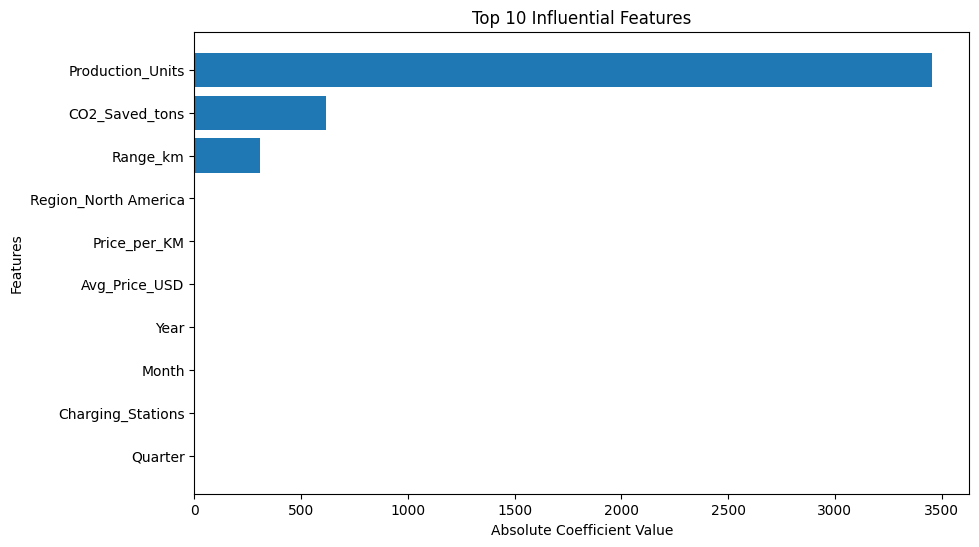

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    coef_df['Feature'].head(10),
    coef_df['Abs_Coefficient'].head(10)
)

plt.title(
    'Top 10 Influential Features'
)

plt.xlabel(
    'Absolute Coefficient Value'
)

plt.ylabel(
    'Features'
)

plt.gca().invert_yaxis()

plt.show()

# **Time Series Forecasting**

In [ ]:
ts = (
    df.groupby('Date')
    ['Estimated_Deliveries']
    .sum()
)

ts.head()

,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


**Time Series Visualization**

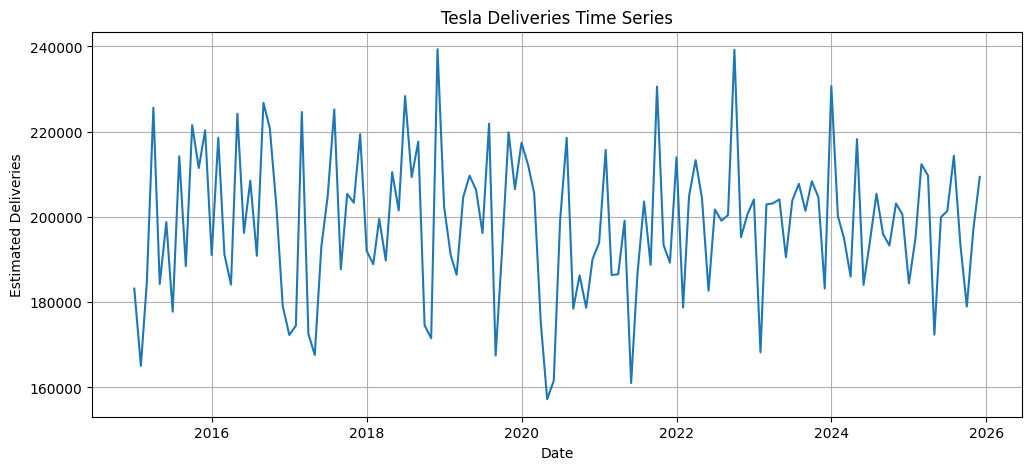

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(ts)

plt.title(
    'Tesla Deliveries Time Series'
)

plt.xlabel('Date')

plt.ylabel('Estimated Deliveries')

plt.grid(True)

plt.show()

The time series plot helps identify long-term trends, seasonal patterns, and fluctuations in Tesla deliveries over time.

 **Stationarity Check (ADF Test)**

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -8.880990349502861
p-value: 1.3181396968154354e-14


In [ ]:
if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

Series is Stationary


**ACF and PACF Plot**

<Figure size 1200x500 with 0 Axes>

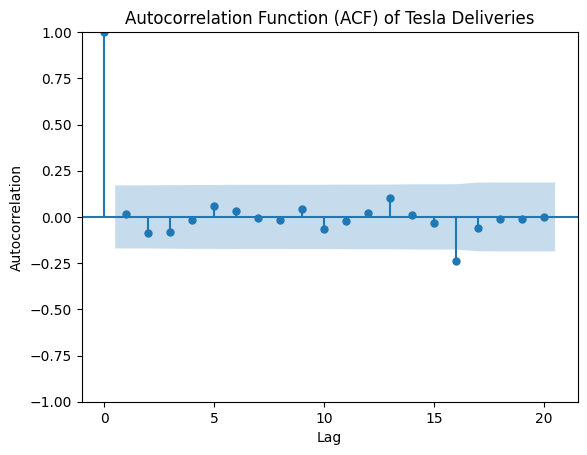

In [ ]:
plt.figure(figsize=(12,5))

plot_acf(
    ts,
    lags=20
)

plt.title(
    'Autocorrelation Function (ACF) of Tesla Deliveries'
)

plt.xlabel('Lag')

plt.ylabel('Autocorrelation')

plt.show()

The ACF plot shows the correlation between current Tesla deliveries and previous lagged observations. Most autocorrelation values lie within the confidence interval, indicating weak serial dependence. This suggests that past delivery values have limited influence on future values beyond a few lags, supporting the stationarity result obtained from the ADF test.

<Figure size 1200x500 with 0 Axes>

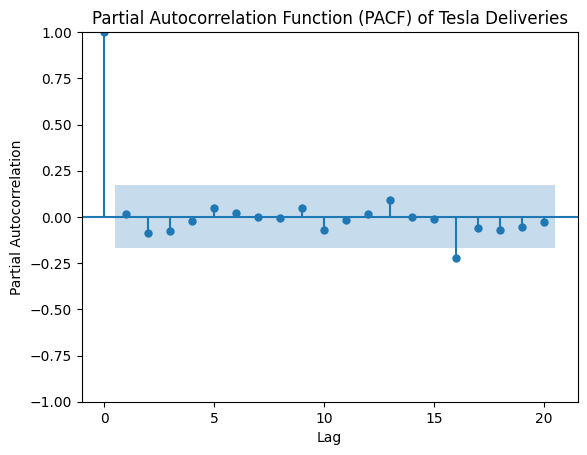

In [ ]:
plt.figure(figsize=(12,5))

plot_pacf(
    ts,
    lags=20
)

plt.title(
    'Partial Autocorrelation Function (PACF) of Tesla Deliveries'
)

plt.xlabel('Lag')

plt.ylabel('Partial Autocorrelation')

plt.show()

The PACF plot measures the direct effect of previous lagged observations after removing the influence of intermediate lags. Most partial autocorrelation values fall within the confidence bounds, indicating that no strong lag structure is present in the series. This suggests that only a small autoregressive component may be required for forecasting.

**ARIMA Forecasting**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    ts,
    order=(1,0,1)
)

model_fit = model.fit()

print(model_fit.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 0, 1)   Log Likelihood               -1469.876
Date:                  Fri, 05 Jun 2026   AIC                           2947.752
Time:                          08:40:40   BIC                           2959.283
Sample:                      01-01-2015   HQIC                          2952.437
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.984e+05    450.258    440.733      0.000    1.98e+05    1.99e+05
ar.L1          0.9286      0.036     25.772      0.000       0.858       0.999
ma.L1         -0.9993      0.138    

An ARIMA(1,0,1) model was fitted to the Tesla deliveries time series. The model indicates a strong dependence of current deliveries on previous observations, as reflected by the AR coefficient (0.9286). Diagnostic statistics such as the Ljung-Box and Jarque-Bera tests suggest that the residuals behave reasonably well, indicating that the model is suitable for short-term forecasting.

# **Forecast Future Deliveries**

In [ ]:
forecast = model_fit.forecast(
    steps=12
)

print(forecast)

2026-01-01    198450.383859
2026-02-01    198449.892651
2026-03-01    198449.436501
2026-04-01    198449.012907
2026-05-01    198448.619546
2026-06-01    198448.254258
2026-07-01    198447.915042
2026-08-01    198447.600036
2026-09-01    198447.307512
2026-10-01    198447.035866
2026-11-01    198446.783607
2026-12-01    198446.549353
Freq: MS, Name: predicted_mean, dtype: float64


 **Forecast Visualization**

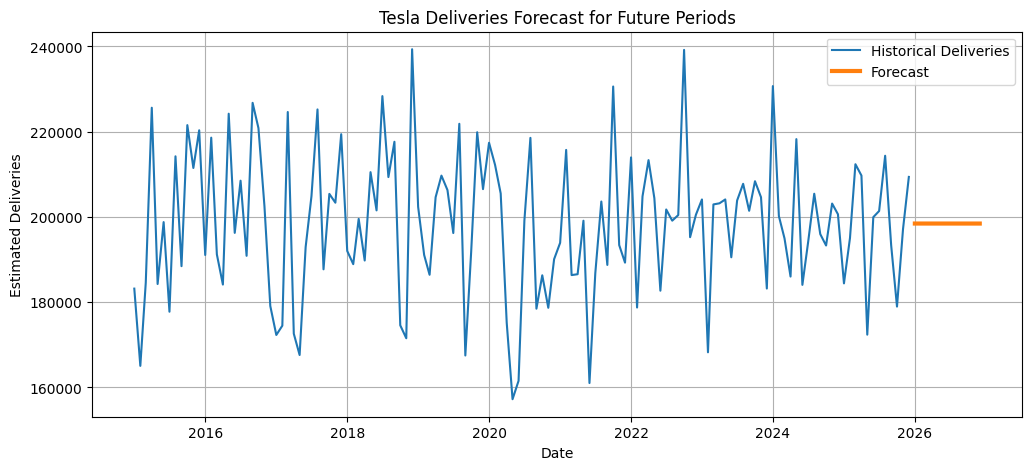

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    ts,
    label='Historical Deliveries'
)

plt.plot(
    forecast.index,
    forecast,
    label='Forecast',
    linewidth=3
)

plt.title(
    'Tesla Deliveries Forecast for Future Periods'
)

plt.xlabel('Date')

plt.ylabel('Estimated Deliveries')

plt.legend()

plt.grid(True)

plt.show()

The ARIMA(1,0,1) model forecasts Tesla deliveries to remain relatively stable over the forecast horizon, with predicted deliveries converging around 198,000 units. Since the time series is stationary and does not exhibit a strong long-term trend, the model expects future deliveries to fluctuate around the historical average rather than experience significant growth or decline.

# **Save Model and Scaler**

In [ ]:
import joblib

# Save trained model
joblib.dump(
    best_model,
    'lasso_model.pkl'
)

# Save scaler
joblib.dump(
    scaler,
    'scaler.pkl'
)

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


# **Download Files in Google Colab**

In [ ]:
from google.colab import files

files.download('lasso_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Load Model Later**

In [ ]:
import joblib

loaded_model = joblib.load(
    'lasso_model.pkl'
)

loaded_scaler = joblib.load(
    'scaler.pkl'
)

print("Model loaded successfully!")

Model loaded successfully!


# **Make New Predictions**

In [ ]:
import joblib

loaded_model = joblib.load('lasso_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

sample = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)

print("Prediction:", prediction)
print("Actual:", y_test.iloc[0])

Prediction: [9218.87913545]
Actual: 8910


The final Lasso Regression model and StandardScaler were saved using Joblib. This allows the trained model to be reused for future predictions without retraining, supporting deployment and production use cases.

# **Data Leakage Prevention**

To ensure realistic model performance:

-Removed non-essential metadata features.

-Maintained chronological ordering of observations.

-Applied scaling only after train-test split.

-Used lag-based features generated from historical data.

-Avoided using target-derived features that could leak future information.

# **Business Insights**

-Tesla deliveries exhibit strong dependence on historical delivery trends.

-Production capacity significantly influences future deliveries.

-Vehicle specifications such as battery capacity and driving range contribute to delivery performance.

-Historical delivery information is one of the strongest predictors of future deliveries.

-Lasso Regression provides an effective balance between predictive accuracy and model simplicity.

-Cross-validation confirms strong model generalization and low risk of overfitting.

-Time series analysis confirmed that the delivery series is stationary.

-ARIMA forecasting suggests relatively stable future delivery levels based on historical patterns.

# **Conclusion**

This project successfully developed an end-to-end machine learning pipeline for analyzing and forecasting Tesla vehicle deliveries using data from 2015–2025. The workflow included data preprocessing, exploratory data analysis, feature engineering, encoding, scaling, model development, cross-validation, hyperparameter tuning, and time series forecasting.

Among the evaluated models, Lasso Regression achieved the best overall performance with an R² score of 0.9885 and a cross-validation score of 0.9906. Time series analysis confirmed stationarity of the delivery data, and ARIMA forecasting provided future delivery estimates based on historical trends. The results demonstrate the effectiveness of machine learning and forecasting techniques in understanding delivery patterns and supporting strategic business decision-making.